<a href="https://colab.research.google.com/github/nahmxp/rl-for-data-scientists/blob/main/notebooks/chapter_04_policies_values/04_bellman_equations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 4 — Policies, Values & Bellman Equations## Concept Notebook[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com)**No GPU required. Runtime: ~25 minutes.**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
print('Ready')

Ready


This code block imports necessary libraries for numerical operations (`numpy`) and plotting (`matplotlib.pyplot`). It also prints 'Ready' to indicate that the environment is set up.

## 4.1 Policy Evaluation: Computing V^πGiven a policy π (a mapping from states to action probabilities), the value function V^π(s) = expected discounted return from state s following π.We compute it by solving the Bellman expectation equation iteratively.

The following code implements the **Policy Evaluation** algorithm for a simple GridWorld environment. We aim to compute the **state-value function** $V^\pi(s)$, which represents the expected discounted return (total future reward) from starting in state $s$ and following a given policy $\pi$.

### GridWorld Setup:
*   **`size`**: Defines the dimensions of the square grid (e.g., 5x5).
*   **`goal`**: The terminal state, reaching which yields a high reward.
*   **`gamma`**: The discount factor ($\gamma$), which determines the importance of future rewards. A value of 0.9 means future rewards are slightly discounted.
*   **`actions`**: Possible movements (Up, Down, Left, Right).

### Random Policy:
*   The current policy $\pi$ is a **random policy**, meaning from any non-goal state, the agent chooses any of the four actions with equal probability (0.25 each).

### Bellman Expectation Equation Iteration:
*   We start with an arbitrary value function `V` (initialized to zeros).
*   In each `iteration`, we update the value of each state $s$ ($V(s)$) based on the Bellman Expectation Equation:
    $V_{k+1}(s) = \sum_a \pi(a|s) \sum_{s', r} P(s', r|s, a) [r + \gamma V_k(s')]$
    For our random policy, this simplifies to averaging the expected returns from all possible actions.
*   **Reward Structure:**
    *   Moving into the `goal` state gives a reward of `+10`.
    *   Any other move (even if it's the goal state) gives a reward of `-1` (a small penalty).
    *   If an action leads off the grid, the agent

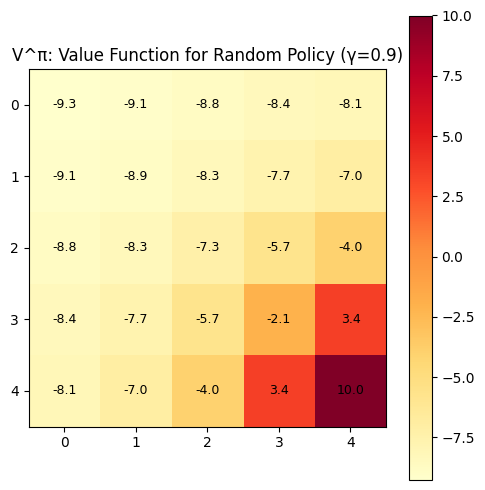

In [2]:
# GridWorld from Ch1 — now computing V values for every cell
size = 5
goal = (4, 4)
gamma = 0.9

# Random policy: uniform over {UP, DOWN, LEFT, RIGHT}
# Bellman iterative evaluation
V = np.zeros((size, size))
actions = [(-1,0),(1,0),(0,-1),(0,1)]  # UP DOWN LEFT RIGHT

for iteration in range(200):
    V_new = np.copy(V)
    for r in range(size):
        for c in range(size):
            if (r,c) == goal:
                V_new[r][c] = 10
                continue
            vs = []
            for dr, dc in actions:
                nr, nc = r+dr, c+dc
                if 0 <= nr < size and 0 <= nc < size:
                    reward = 10 if (nr,nc)==goal else -1
                    vs.append(reward + gamma * V[nr][nc])
                else:
                    vs.append(-1 + gamma * V[r][c])  # bounce back
            V_new[r][c] = np.mean(vs)  # random policy: average
    V = V_new

fig, ax = plt.subplots(figsize=(5,5))
im = ax.imshow(V, cmap='YlOrRd')
for r in range(size):
    for c in range(size):
        ax.text(c, r, f'{V[r][c]:.1f}', ha='center', va='center', fontsize=9)
ax.set_title('V^π: Value Function for Random Policy (γ=0.9)')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

The heatmap above visualizes the calculated $V^\pi(s)$ values for each state in the GridWorld. Higher values (darker red) indicate states from which the expected discounted return is greater under the random policy. As expected, states closer to the goal have higher values, even under a random policy.

## 4.2 Policy Improvement: Greedy Policy from VGiven V^π, we can always find a better policy π' by acting greedily:π'(s) = argmax_a [R(s,a) + γ Σ P(s'|s,a) V^π(s')]

Now that we have computed the state-value function $V^\pi(s)$ for our random policy, we can use it to find a **better policy** $\pi'$. This process is called **Policy Improvement**. The idea is to act **greedily** with respect to the current value function $V^\pi(s)$.

For each state $s$, we consider all possible actions $a$. For each action, we calculate the expected return of taking that action and then following policy $\pi$ thereafter. The action that yields the highest expected return is chosen as the greedy action for that state.

Mathematically, the greedy policy $\pi'(s)$ selects the action $a$ that maximizes:

$Q^\pi(s,a) = R(s,a) + \gamma \sum_{s'} P(s'|s,a) V^\pi(s')$

Where:
*   $R(s,a)$ is the immediate reward for taking action $a$ in state $s$.
*   $P(s'|s,a)$ is the probability of transitioning to state $s'$ after taking action $a$ in state $s$.
*   $V^\pi(s')$ is the value of the next state $s'$ under the current policy $\pi$.

The code below iterates through each state, calculates the $Q$-value for each possible action, and then assigns the action that results in the maximum $Q$-value to the `policy_arrows` grid, representing the improved greedy policy.

In [3]:
# Derive greedy policy from V
policy_arrows = np.full((size, size), '·')
action_symbols = {(-1,0):'↑',(1,0):'↓',(0,-1):'←',(0,1):'→'}

for r in range(size):
    for c in range(size):
        if (r,c) == goal:
            policy_arrows[r][c] = '★'
            continue
        best_val, best_action = -999, None
        for dr, dc in actions:
            nr, nc = r+dr, c+dc
            if 0 <= nr < size and 0 <= nc < size:
                val = (10 if (nr,nc)==goal else -1) + gamma * V[nr][nc]
            else:
                val = -1 + gamma * V[r][c]
            if val > best_val:
                best_val, best_action = val, (dr, dc)
        policy_arrows[r][c] = action_symbols[best_action]

print('Greedy Policy (arrows show where to move):')
for row in policy_arrows:
    print('  ' + '  '.join(row))

Greedy Policy (arrows show where to move):
  ↓  →  ↓  ↓  ↓
  ↓  ↓  ↓  ↓  ↓
  →  →  ↓  ↓  ↓
  →  →  →  ↓  ↓
  →  →  →  →  ★


The output above shows the **Greedy Policy** derived from the value function $V^\pi$. Each arrow indicates the optimal action to take from that state to maximize the immediate reward plus the discounted future reward (assuming subsequent actions still follow the original random policy). Notice how the arrows generally point towards the goal state (`★`), demonstrating that we've found a policy that is significantly better than the purely random one.

## ✅ Key Takeaways1. V^π(s) = expected discounted return from s following π — computed by Bellman iteration2. Q^π(s,a) = V^π(s) but with the first action fixed — enables policy improvement3. Policy iteration: evaluate → improve → evaluate → improve → converges to π*4. The Bellman *optimality* equation finds V* directly (Chapter 5)